# IE7615 — Discriminative Project, Milestone 1
## Comparing CNN approaches for 73-class object recognition

| Stage | What happens |
|---|---|
| 1. Data | unzip → find the 73 class folders → skip junk (.DS_Store, .claude, __MACOSX) → verify every image → filename vs Object ID check (e.g. `Sunglasses_001.jpg`; labels always come from the **folder**) → MD5 de-duplication → **remove background-only images** → images used at **224×224** |
| 2. Split | stratified 70 / 15 / 15, seed 42, saved to Drive |
| 3. Checks | label audit (out-of-fold) · near-duplicate check → **hard test subset** |
| 4. Models | 5 models by default (`RUN_MODELS` in settings): **A2** custom CNN from scratch · **C** ResNet-50 · **D** EfficientNet-B0 · **E** ConvNeXt-Tiny · **G** DenseNet-121 (C–G: the 4 best across both earlier runs). A1, B and F are defined but switched off |
| 5. Training | robust augmentation, AdamW with head/backbone LRs, warm-up + cosine, label smoothing, class weights, AMP, early stopping on val macro-F1, resume-safe |
| 6. Results | comparison table (CI, hard subset, top-5, TTA, speed) · robustness · selection on validation only · McNemar · curves · **misclassified images for every model (val + test)** · confusion matrix · Grad-CAM · background-shortcut test · summary file |

**How to run:** Runtime → Change runtime type → **T4 GPU** → Runtime → **Run all** (about 2 h for the 5 default models).
If Colab disconnects, reconnect and **Run all** again: finished models are skipped and an unfinished one resumes from its last epoch.

## 1. Setup

In [ ]:
!nvidia-smi -L || echo "No GPU - switch runtime to T4 GPU"

GPU 0: Tesla T4 (UUID: GPU-d39052d0-2034-2ec5-52ef-70f2fbb38c81)


In [ ]:
import os, re, io, json, time, math, random, hashlib, shutil, subprocess, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter, ImageEnhance, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from scipy.stats import binomtest

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ---------------- paths ----------------
ZIP_PATH    = "/content/drive/MyDrive/IE7615DeepLearning.zip"
EXTRACT_DIR = os.environ.get("IE_DATA_DIR", "/content/data")      # unzip target (fast local disk)
SAVE_DIR    = os.environ.get("IE_SAVE_DIR", "/content/drive/MyDrive/IE7615_project_v3")  # results survive disconnects
#os.makedirs(SAVE_DIR, exist_ok=True)
#FIG_DIR = Path(SAVE_DIR, "figures"); FIG_DIR.mkdir(exist_ok=True)
FIG_DIR = Path(SAVE_DIR, "figures")

# ---------------- settings ----------------
SEED        = 42
IMG_SIZE    = 224                      # images are already 224x224
BG_REGEX    = re.compile(r"_bg_|bg\d+", re.IGNORECASE)   # background-only shots, e.g. OBJ012_bg_03.jpg, bg1.jpg
DROP_ID_MISMATCH = False               # True = drop images whose filename names a DIFFERENT Object ID than their folder
NEAR_DUP_THRESHOLD = 0.92              # cosine similarity above which a test image is "near-duplicate" of a train image
PRIVATE_FILES = {"OBJ054_017.jpg"}    # blurred in every figure: the OBJ054 phone screenshot
# Models to train and compare. Defined but off: "A1_CustomCNN_w512", "B_ConvNeXtT_probe", "F_ConvNeXtT_basic".
# To use A1_CustomCNN_w512 custom CNN instead of A2_CustomCNN_w384, replace "A2_CustomCNN_w384" with "A1_CustomCNN_w512".
RUN_MODELS = ["A2_CustomCNN_w384", "C_ResNet50", "D_EfficientNetB0", "E_ConvNeXtT", "G_DenseNet121"]
QUICK_TEST  = False                    # True = 2 epochs per model, for a fast dry run of the whole notebook
PRETRAINED  = os.environ.get("IE_PRETRAINED", "1") == "1"

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
seed_everything()
print("Colab:", IN_COLAB, "| save dir:", SAVE_DIR)

Colab: True | save dir: /content/drive/MyDrive/IE7615_project_v3


In [ ]:
# Mount Drive, create results folders, unzip the dataset to local disk
if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        # Not mounted: anything under /content/drive is a stray LOCAL folder from the earlier error, safe to remove
        if os.path.exists("/content/drive"):
            shutil.rmtree("/content/drive")
        drive.mount("/content/drive")
    else:
        print("Drive already mounted")
    if not (os.path.isdir(EXTRACT_DIR) and any(Path(EXTRACT_DIR).iterdir())):
        assert os.path.exists(ZIP_PATH), f"Zip not found at {ZIP_PATH}"
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        subprocess.run(["unzip", "-q", "-o", ZIP_PATH, "-d", EXTRACT_DIR], check=True)
        print("Unzipped to", EXTRACT_DIR)
    else:
        print("Already unzipped:", EXTRACT_DIR)

os.makedirs(SAVE_DIR, exist_ok=True); FIG_DIR.mkdir(exist_ok=True)
print("Results will be saved in:", SAVE_DIR)
print(os.listdir(EXTRACT_DIR))

Mounted at /content/drive
Unzipped to /content/data
Results will be saved in: /content/drive/MyDrive/IE7615_project_v3
['IE7615 Deep Learning for AI']


## 2. Data audit and cleaning
Order matters: index the dataset, skip junk, verify every image, check names, de-duplicate, then remove background images.
**Labels always come from the folder name**, never the filename. So a student who named files `Sunglasses_001.jpg` doesn't break anything. We still report those files.

In [ ]:
IMG_EXT   = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
JUNK_DIRS = {"__MACOSX", ".claude", ".ipynb_checkpoints", ".git", ".Trash"}

def is_junk_dir(name):
    return name.startswith(".") or name in JUNK_DIRS

def find_class_root(base):
    # The class root is the folder with the most sub-folders that contain images.
    best, best_n = None, 0
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if not is_junk_dir(d)]
        n = sum(1 for d in dirs
                if any(Path(root, d, f).suffix.lower() in IMG_EXT for f in os.listdir(Path(root, d))))
        if n > best_n:
            best, best_n = root, n
    return Path(best), best_n

CLASS_ROOT, n_cls = find_class_root(EXTRACT_DIR)
print(f"Class root: {CLASS_ROOT}  ({n_cls} class folders)")

rows, junk = [], []
for cdir in sorted(p for p in CLASS_ROOT.iterdir() if p.is_dir()):
    if is_junk_dir(cdir.name):
        junk.append(str(cdir)); continue
    for root, dirs, files in os.walk(cdir):
        for d in dirs:
            if is_junk_dir(d): junk.append(str(Path(root, d)))
        dirs[:] = [d for d in dirs if not is_junk_dir(d)]
        for f in sorted(files):
            p = Path(root, f)
            if f.startswith(".") or p.suffix.lower() not in IMG_EXT:
                junk.append(str(p)); continue
            rows.append({"path": str(p), "label": cdir.name, "fname": f})

raw_df = pd.DataFrame(rows)
print(f"Indexed {len(raw_df)} image files in {raw_df.label.nunique()} folders; skipped {len(junk)} junk entries")
for j in junk[:20]: print("  skipped:", j)

Class root: /content/data/IE7615 Deep Learning for AI  (73 class folders)
Indexed 7343 image files in 73 folders; skipped 2 junk entries
  skipped: /content/data/IE7615 Deep Learning for AI/images_OBJ036/.claude
  skipped: /content/data/IE7615 Deep Learning for AI/images_OBJ036/.DS_Store


In [ ]:
# Verify every image opens, and record size / colour mode
def inspect(path):
    try:
        with Image.open(path) as im: im.verify()
        with Image.open(path) as im: return im.size[0], im.size[1], im.mode, True
    except Exception:
        return None, None, None, False

info = [inspect(p) for p in raw_df.path]
raw_df[["w", "h", "mode", "ok"]] = pd.DataFrame(info, index=raw_df.index)
bad = raw_df[~raw_df.ok]
print(f"Corrupt / unreadable: {len(bad)}")
if len(bad): print(bad[["label", "fname"]].to_string())
df = raw_df[raw_df.ok].copy()
df[["w", "h"]] = df[["w", "h"]].astype(int)

Corrupt / unreadable: 0


In [ ]:
# Filename vs Object ID check. The folder is ground truth; this only REPORTS problems.
def obj_id(s):
    m = re.search(r"OBJ[_\- ]?0*(\d+)", s, re.IGNORECASE)
    return int(m.group(1)) if m else None

df["folder_id"] = df.label.map(obj_id)
df["file_id"]   = df.fname.map(obj_id)
df["id_status"] = np.where(df.file_id.isna(), "no_id_in_filename",
                   np.where(df.file_id == df.folder_id, "ok", "id_mismatch"))
print(df.id_status.value_counts().to_string())
issues = df[df.id_status != "ok"].groupby(["label", "id_status"]).size().rename("n").reset_index()
if len(issues):
    print("\nFolders with filename issues (labels still taken from the folder, so these are safe):")
    print(issues.to_string(index=False))
    print("\nExamples:", df[df.id_status != "ok"].fname.head(8).tolist())
if DROP_ID_MISMATCH:
    n0 = len(df); df = df[df.id_status != "id_mismatch"]; print(f"Dropped {n0-len(df)} id_mismatch files")

id_status
ok                   7243
no_id_in_filename     100

Folders with filename issues (labels still taken from the folder, so these are safe):
        label         id_status   n
images_OBJ014 no_id_in_filename 100

Examples: ['sunglasses_001.jpeg', 'sunglasses_002.jpeg', 'sunglasses_003.jpeg', 'sunglasses_004.jpeg', 'sunglasses_005.jpeg', 'sunglasses_006.jpeg', 'sunglasses_007.jpeg', 'sunglasses_008.jpeg']


In [ ]:
# Background-only image removal - done BEFORE de-duplication, so the duplicate count below is real object photos only.
# Background photos are kept aside (bg_df) for the background-shortcut test at the end.
df["is_bg"] = df.fname.str.contains(BG_REGEX)
bg_df  = df[df.is_bg].copy()
obj_df = df[~df.is_bg].copy()
n_bg_raw = len(bg_df)
print(f"Background images removed: {n_bg_raw}  (from {bg_df.label.nunique()} folders)")
print(f"Object images kept:        {len(obj_df)}")
print("Example bg names:", bg_df.fname.head(6).tolist())

Background images removed: 385  (from 72 folders)
Object images kept:        6958
Example bg names: ['OBJ001_bg_001.jpg', 'OBJ001_bg_002.jpg', 'OBJ001_bg_003.jpg', 'OBJ001_bg_004.jpg', 'OBJ001_bg_005.jpg', 'OBJ002_bg_001.jpg']


In [ ]:
# Exact-duplicate removal (MD5 of file bytes) on the OBJECT photos.
# A duplicate that appears under TWO different labels is ambiguous: all copies are dropped.
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

obj_df["md5"] = [md5(p) for p in obj_df.path]
grp = obj_df.groupby("md5").label.nunique()
conflict_md5 = set(grp[grp > 1].index)
n_conflict = int(obj_df.md5.isin(conflict_md5).sum())
obj_df = obj_df[~obj_df.md5.isin(conflict_md5)]
n_before = len(obj_df)
obj_df = obj_df.sort_values("path").drop_duplicates("md5", keep="first")
n_dup = n_before - len(obj_df)
removed_dups = df[~df.is_bg & ~df.path.isin(obj_df.path)][["label", "fname"]]
removed_dups.to_csv(Path(SAVE_DIR, "removed_duplicates.csv"), index=False)

bg_df["md5"] = [md5(p) for p in bg_df.path]                   # background copies: de-duplicated separately
n_bg_dup = len(bg_df) - bg_df.md5.nunique()
bg_df = bg_df.sort_values("path").drop_duplicates("md5", keep="first")

print(f"Object photos - same-class exact duplicates removed: {n_dup}")
print(f"Object photos - cross-class conflicting copies removed: {n_conflict}")
print(f"(Background photos had {n_bg_dup} duplicates among themselves; they are not used for training anyway)")
print(f"Object images remaining: {len(obj_df)}")

Object photos - same-class exact duplicates removed: 16
Object photos - cross-class conflicting copies removed: 0
(Background photos had 7 duplicates among themselves; they are not used for training anyway)
Object images remaining: 6942


In [ ]:
# Size / mode check. 224x224 is the standard. Any other size is resized to 224 when loaded (nothing on disk changes).
odd = obj_df[(obj_df.w != IMG_SIZE) | (obj_df.h != IMG_SIZE)]
print(f"Images not {IMG_SIZE}x{IMG_SIZE}: {len(odd)}  (resized to {IMG_SIZE} at load time)")
if len(odd): print(odd[["label", "fname", "w", "h"]].head(10).to_string(index=False))
print("Colour modes:", obj_df["mode"].value_counts().to_dict(), "(all converted to RGB at load time)")

Images not 224x224: 2  (resized to 224 at load time)
        label          fname   w   h
images_OBJ003 OBJ003_072.jpg 224 192
images_OBJ023 OBJ023_001.JPG 225 224
Colour modes: {'RGB': 6942} (all converted to RGB at load time)


73 classes | final images: 6942 | per class min 89, median 95, max 106 | imbalance ratio 1.19


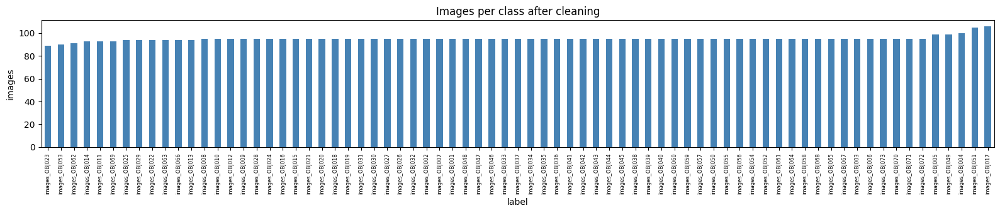

In [ ]:
# Per-class counts table (for the report)
counts = pd.DataFrame({
    "indexed":     raw_df.groupby("label").size(),
    "bg_removed":  df[df.is_bg].groupby("label").size(),
    "final":       obj_df.groupby("label").size(),
}).fillna(0).astype(int)
counts.to_csv(Path(SAVE_DIR, "class_counts.csv"))
print(f"{len(counts)} classes | final images: {counts.final.sum()} | per class min {counts.final.min()}, "
      f"median {int(counts.final.median())}, max {counts.final.max()} | imbalance ratio {counts.final.max()/counts.final.min():.2f}")
small = counts[counts.final < 30]
if len(small): print("WARNING - classes with < 30 images:\n", small.to_string())

fig, ax = plt.subplots(figsize=(16, 3.5))
counts.final.sort_values().plot.bar(ax=ax, color="steelblue")
ax.set_title("Images per class after cleaning"); ax.set_ylabel("images"); ax.tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.savefig(FIG_DIR / "class_counts.png", dpi=150); plt.show()

## 3. Stratified 70 / 15 / 15 split (seed 42)

In [ ]:
obj_df = obj_df.sort_values("path").reset_index(drop=True)   # sorted so the split is reproducible
CLASSES = sorted(obj_df.label.unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
obj_df["label_idx"] = obj_df.label.map(CLASS_TO_IDX)

train_df, temp_df = train_test_split(obj_df, test_size=0.30, stratify=obj_df.label, random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df.label, random_state=SEED)
cols = ["path", "label", "label_idx", "fname"]
train_df, val_df, test_df = (d[cols].reset_index(drop=True) for d in (train_df, val_df, test_df))
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    d.to_csv(Path(SAVE_DIR, f"{name}_split.csv"), index=False)
    print(f"{name:5s}: {len(d):5d} images, {d.label.nunique()} classes")
assert not (set(train_df.path) & set(val_df.path) or set(train_df.path) & set(test_df.path) or set(val_df.path) & set(test_df.path))
Path(SAVE_DIR, "classes.json").write_text(json.dumps(CLASSES), encoding="utf-8")
SPLIT_SIG = hashlib.md5("|".join(f"{n}:{p}" for n, d in [("tr", train_df), ("va", val_df), ("te", test_df)] for p in sorted(d.path)).encode()).hexdigest()[:12]
print("Split signature:", SPLIT_SIG, "(stored with every trained model; a different split forces retraining)")

train:  4859 images, 73 classes
val  :  1041 images, 73 classes
test :  1042 images, 73 classes
Split signature: 8f5b9bed36df (stored with every trained model; a different split forces retraining)


### Privacy: find screenshots automatically
We found a phone screenshot with someone's name and number in OBJ054. This cell scores **every** image with CLIP (zero-shot: "screenshot of a phone screen" vs "photo of an object").
Flagged files go into `PRIVATE_FILES` and are **blurred in every figure** in this notebook. They stay in the dataset, because it is locked and nothing is deleted.
* To add a file by hand, put its name in `PRIVATE_FILES` in the settings cell.
* If a normal photo is wrongly flagged, put its name in `NOT_PRIVATE` below.

In [ ]:
AUTO_DETECT_SCREENSHOTS = True
SCREENSHOT_THRESHOLD    = 0.60     # probability of "screenshot" needed to flag an image
NOT_PRIVATE             = set()    # wrongly flagged normal photos, e.g. {"OBJ054_003.jpg"}

if AUTO_DETECT_SCREENSHOTS:
    try:
        import torch
        from transformers import CLIPModel, CLIPProcessor
        dev = "cuda" if torch.cuda.is_available() else "cpu"
        clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(dev).eval()
        proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        prompts = ["a screenshot of a phone screen with text",          # screenshot prompts first
                   "a screenshot of a messaging app or a contact card",
                   "a photo of an object", "a photo of a household item on a table", "a photo of a room"]
        N_SHOT = 2
        txt = proc(text=prompts, return_tensors="pt", padding=True)
        txt = {k: v.to(dev) for k, v in txt.items()}
        scan_df = pd.concat([obj_df, bg_df])[["path", "label", "fname"]].reset_index(drop=True)
        scores = []
        with torch.no_grad():
            for i in range(0, len(scan_df), 64):
                imgs = [ImageOps.exif_transpose(Image.open(p)).convert("RGB") for p in scan_df.path[i:i + 64]]
                px = proc(images=imgs, return_tensors="pt")["pixel_values"].to(dev)
                probs = clip(pixel_values=px, **txt).logits_per_image.softmax(-1)
                scores.append(probs[:, :N_SHOT].sum(1).float().cpu())
        scan_df["screenshot_prob"] = torch.cat(scores).numpy()
        del clip; torch.cuda.empty_cache() if dev == "cuda" else None
        scan_df.sort_values("screenshot_prob", ascending=False).to_csv(Path(SAVE_DIR, "screenshot_scan.csv"), index=False)

        flagged = scan_df[(scan_df.screenshot_prob >= SCREENSHOT_THRESHOLD) & ~scan_df.fname.isin(NOT_PRIVATE)]
        PRIVATE_FILES |= set(flagged.fname)
        print(f"Scanned {len(scan_df)} images. Flagged as screenshots (blurred in all figures): {len(flagged)}")
        print(flagged.sort_values("screenshot_prob", ascending=False)[["label", "fname", "screenshot_prob"]].round(3).to_string(index=False))
        print("\nTop 5 OBJ054 scores (the known screenshot should be at the top):")
        print(scan_df[scan_df.label.str.contains("054")].nlargest(5, "screenshot_prob")[["fname", "screenshot_prob"]].round(3).to_string(index=False))
    except Exception as e:
        print("Automatic screenshot scan failed:", repr(e))
        print("-> Add the screenshot's file name to PRIVATE_FILES in the settings cell by hand.")
print("PRIVATE_FILES:", sorted(PRIVATE_FILES))

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Scanned 7320 images. Flagged as screenshots (blurred in all figures): 12
        label          fname  screenshot_prob
images_OBJ054 OBJ054_017.jpg            1.000
images_OBJ016 OBJ016_051.jpg            0.961
images_OBJ034 OBJ034_051.jpg            0.919
images_OBJ016 OBJ016_061.jpg            0.855
images_OBJ016 OBJ016_072.jpg            0.796
images_OBJ016 OBJ016_074.jpg            0.706
images_OBJ016 OBJ016_073.jpg            0.691
images_OBJ016 OBJ016_070.jpg            0.691
images_OBJ016 OBJ016_021.jpg            0.646
images_OBJ016 OBJ016_082.jpg            0.642
images_OBJ016 OBJ016_071.jpg            0.630
images_OBJ016 OBJ016_046.jpg            0.615

Top 5 OBJ054 scores (the known screenshot should be at the top):
         fname  screenshot_prob
OBJ054_017.jpg            1.000
OBJ054_007.jpg            0.039
OBJ054_082.jpg            0.025
OBJ054_094.jpg            0.012
OBJ054_022.jpg            0.011
PRIVATE_FILES: ['OBJ016_021.jpg', 'OBJ016_046.jpg', 'OBJ016_051.jpg', '

## 4. Data pipeline and augmentation
* **Robust augmentation** (every model except F): RandomResizedCrop(0.5–1.0) · **zoom-out** (object shrunk onto a blurred copy of the photo, so it looks far away) · horizontal flip · TrivialAugmentWide · RandomErasing (mimics occlusion)
* **Basic augmentation** (model F only, the ablation): RandomResizedCrop(0.8–1.0) + flip
* **Val / test:** no augmentation, ImageNet normalisation only

torch 2.11.0+cu130 | torchvision 0.26.0+cu130 | device cuda (Tesla T4)


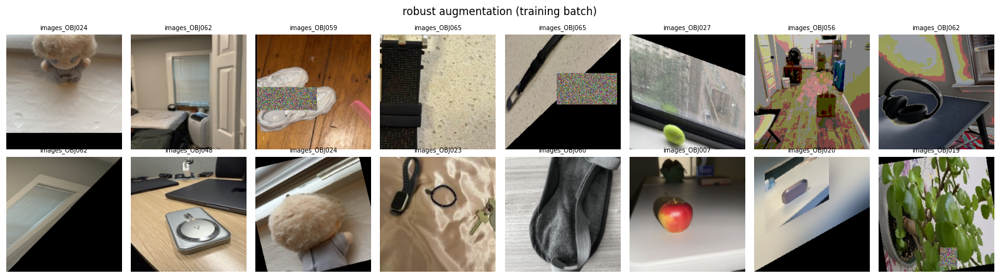

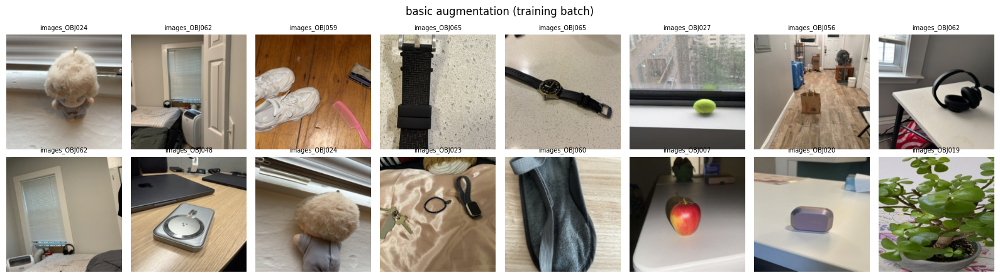

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms as T, models
from torch.utils.data import Dataset, DataLoader

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
EVAL_BS = 64
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device", DEVICE,
      f"({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")

def load_rgb(path):
    img = Image.open(path)
    if img.format == "JPEG": img.draft("RGB", (IMG_SIZE * 2, IMG_SIZE * 2))   # fast decode of any very large JPEG
    img = ImageOps.exif_transpose(img).convert("RGB")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)                # squash, never centre-crop
    return img

def show_img(ax, path, title="", color="black"):
    # Shows an image in a figure; files listed in PRIVATE_FILES are blurred (e.g. screenshots with personal details).
    img = load_rgb(path)
    if Path(path).name in PRIVATE_FILES:
        img = img.filter(ImageFilter.GaussianBlur(25)); title = "(hidden: private)\n" + title
    ax.imshow(img); ax.set_title(title, fontsize=7, color=color); ax.axis("off")

class RandomZoomOut:
    # Shrink the image and paste it on a heavily blurred copy of itself (object looks farther away).
    def __init__(self, p=0.25, scale=(0.45, 0.85)):
        self.p, self.scale = p, scale
    def __call__(self, img):
        if random.random() > self.p: return img
        w, h = img.size; s = random.uniform(*self.scale)
        nw, nh = max(1, int(w * s)), max(1, int(h * s))
        canvas = img.filter(ImageFilter.GaussianBlur(20))
        canvas.paste(img.resize((nw, nh), Image.BICUBIC), (random.randint(0, w - nw), random.randint(0, h - nh)))
        return canvas

robust_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), ratio=(0.8, 1.25)),
    RandomZoomOut(p=0.25, scale=(0.45, 0.85)),
    T.RandomHorizontalFlip(),
    T.TrivialAugmentWide(),
    T.ToTensor(), T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15), value="random"),
])
basic_tf = T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), T.RandomHorizontalFlip(),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
eval_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
AUGS = {"robust": robust_tf, "basic": basic_tf}

class ObjectDataset(Dataset):
    def __init__(self, frame, transform, pil_fn=None):
        self.paths = frame.path.tolist(); self.labels = frame.label_idx.tolist()
        self.transform, self.pil_fn = transform, pil_fn
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = load_rgb(self.paths[i])
        if self.pil_fn is not None: img = self.pil_fn(img, i)
        return self.transform(img), self.labels[i]

def make_loader(frame, transform, shuffle=False, bs=EVAL_BS, pil_fn=None):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(ObjectDataset(frame, transform, pil_fn), batch_size=bs, shuffle=shuffle, generator=g,
                      num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")

def denorm(x):
    return (x.detach().cpu().float() * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)).clamp(0, 1).permute(1, 2, 0).numpy()

for aug_name, tf in AUGS.items():
    xb, yb = next(iter(make_loader(train_df[~train_df.fname.isin(PRIVATE_FILES)], tf, shuffle=True, bs=16)))
    fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
    for ax, x, y in zip(axes.flat, xb, yb):
        ax.imshow(denorm(x)); ax.set_title(CLASSES[int(y)], fontsize=7); ax.axis("off")
    plt.suptitle(f"{aug_name} augmentation (training batch)"); plt.tight_layout()
    plt.savefig(FIG_DIR / f"augmented_batch_{aug_name}.png", dpi=110); plt.show()

## 5. Data-quality checks: label audit and hard test subset
Both checks use features from a **frozen ImageNet ConvNeXt-Tiny**. These are diagnostics only and change nothing in the data.

* **Label audit:** a logistic-regression classifier is scored with 5-fold cross-validation, so every image is judged by a model that never saw it. High out-of-fold accuracy means the labels are clean. Images it confidently assigns to a *different* Object ID are shown as "suspects" so you can check them by eye.
* **Hard test subset:** students often take burst shots. A test image whose most similar **same-class** training image has cosine similarity ≥ 0.92 counts as a near-duplicate. Accuracy on the remaining *hard* images is a more honest measure.

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 184MB/s] 


Label audit: out-of-fold accuracy 97.9% (high = labels are consistent)
50 suspect images (confidently look like another Object ID) -> label_audit_suspects.csv


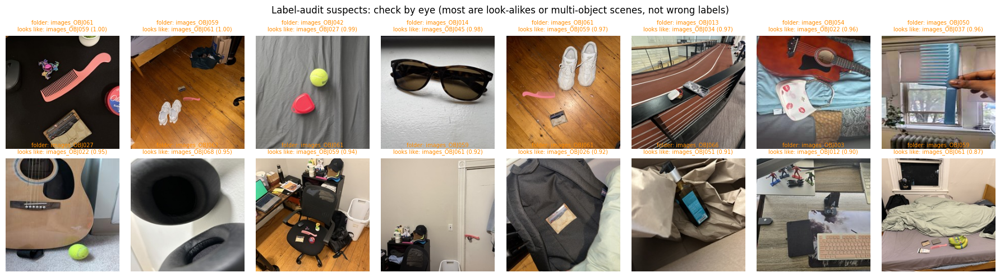

Near-duplicates in test: 99 | hard subset: 943 / 1042 images


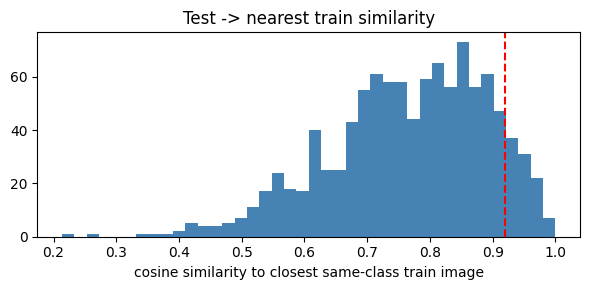

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict

@torch.no_grad()
def extract_features(frame, fe):
    out = []
    for x, _ in make_loader(frame, eval_tf, bs=128):
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            out.append(fe(x.to(DEVICE)).float().cpu())
    return torch.cat(out)

fe = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if PRETRAINED else None)
fe.classifier[2] = nn.Identity(); fe = fe.to(DEVICE).eval()
all_df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")], ignore_index=True)
FEATS = extract_features(all_df, fe)
del fe; torch.cuda.empty_cache()

# ---- label audit (out-of-fold) ----
y_all = all_df.label_idx.values
n_folds = int(min(5, np.bincount(y_all).min()))
clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=2000))
oof = cross_val_predict(clf, FEATS.numpy(), y_all, n_jobs=-1, cv=StratifiedKFold(n_folds, shuffle=True, random_state=SEED),
                        method="predict_proba")
all_df["oof_pred"] = oof.argmax(1); all_df["oof_conf"] = oof.max(1)
print(f"Label audit: out-of-fold accuracy {100*np.mean(all_df.oof_pred == y_all):.1f}% "
      f"(high = labels are consistent)")
suspects = all_df[(all_df.oof_pred != y_all) & (all_df.oof_conf > 0.6)].sort_values("oof_conf", ascending=False)
suspects.assign(suggested=lambda d: d.oof_pred.map(lambda i: CLASSES[i]))[["path", "label", "suggested", "oof_conf"]] \
        .to_csv(Path(SAVE_DIR, "label_audit_suspects.csv"), index=False)
print(f"{len(suspects)} suspect images (confidently look like another Object ID) -> label_audit_suspects.csv")
if len(suspects):
    k = min(16, len(suspects)); fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for ax in axes.flat: ax.axis("off")
    for ax, (_, r) in zip(axes.flat, suspects.head(k).iterrows()):
        show_img(ax, r.path, f"folder: {r.label}\nlooks like: {CLASSES[r.oof_pred]} ({r.oof_conf:.2f})", "darkorange")
    plt.suptitle("Label-audit suspects: check by eye (most are look-alikes or multi-object scenes, not wrong labels)")
    plt.tight_layout(); plt.savefig(FIG_DIR / "label_audit_suspects.png", dpi=120); plt.show()

# ---- near-duplicate check: each test image vs training images of the SAME class ----
Fn = F.normalize(FEATS, dim=1)
tr_mask, te_mask = (all_df.split == "train").values, (all_df.split == "test").values
sim = Fn[te_mask] @ Fn[tr_mask].T
same = torch.tensor(all_df.label_idx.values[te_mask])[:, None] == torch.tensor(all_df.label_idx.values[tr_mask])[None, :]
sim[~same] = -1
test_df["max_sim_train"] = sim.max(1).values.numpy()
test_df["hard"] = test_df.max_sim_train < NEAR_DUP_THRESHOLD
test_df.to_csv(Path(SAVE_DIR, "test_split.csv"), index=False)
print(f"Near-duplicates in test: {(~test_df.hard).sum()} | hard subset: {test_df.hard.sum()} / {len(test_df)} images")
plt.figure(figsize=(6, 3)); plt.hist(test_df.max_sim_train, bins=40, color="steelblue")
plt.axvline(NEAR_DUP_THRESHOLD, color="red", ls="--"); plt.xlabel("cosine similarity to closest same-class train image")
plt.title("Test -> nearest train similarity"); plt.tight_layout(); plt.savefig(FIG_DIR / "near_dup_hist.png", dpi=120); plt.show()

## 6. Models
By default 5 best models run: **A2, C, D, E, G** (set in `RUN_MODELS` in the settings cell). A1, B and F are defined below but switched off. We can add their names to `RUN_MODELS` to include them.

| ID | Model | Question it answers |
|---|---|---|
| **A1** | Custom CNN, widths up to 512, 30 epochs, batch 64, lr 1e-3 | baseline with no pretraining |
| **A2** | Custom CNN, widths up to 384, Kaiming init, 60 epochs, batch 32, lr 2e-3 | does a longer, tuned schedule help a scratch CNN? |
| B | ConvNeXt-Tiny, **frozen**, only last layer trained (linear probe) | are ImageNet features alone enough? |
| **C** | ResNet-50, fine-tuned | classic residual CNN |
| **D** | EfficientNet-B0, fine-tuned| small, efficient CNN |
| **E** | ConvNeXt-Tiny, fine-tuned | modern CNN |
| F | ConvNeXt-Tiny, fine-tuned, **basic** augmentation| ablation: does the robust augmentation help? |
| **G** | DenseNet-121, fine-tuned | dense connections, strong on small data |

**Why these four pretrained models (C, D, E, G):** they are the top 4 fine-tuned models across both earlier runs. MobileNetV3-L (95.6%) and EfficientNetV2-S (96.4%) were dropped.
The earlier numbers came from different splits and cleaning, so they were only used to choose. Every model here is retrained on the same split.

In [ ]:
class CustomCNN(nn.Module):
    # VGG-style: 5 stages of [conv3x3-BN-ReLU] x2 + max-pool (224 -> 7), global average pooling, dropout, linear.
    def __init__(self, n_classes, widths=(32, 64, 128, 256, 512), dropout=0.3, kaiming=False):
        super().__init__()
        stages, cin = [], 3
        for w in widths:
            stages.append(nn.Sequential(
                nn.Conv2d(cin, w, 3, padding=1, bias=False), nn.BatchNorm2d(w), nn.ReLU(inplace=True),
                nn.Conv2d(w, w, 3, padding=1, bias=False),   nn.BatchNorm2d(w), nn.ReLU(inplace=True),
                nn.MaxPool2d(2)))
            cin = w
        self.features = nn.Sequential(*stages)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, n_classes))
        if kaiming:
            for m in self.modules():
                if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                elif isinstance(m, nn.BatchNorm2d): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

W = lambda w: w if PRETRAINED else None

def build_convnext(n, frozen=False):
    m = models.convnext_tiny(weights=W(models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1))
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, n)
    if frozen:
        for name, p in m.named_parameters(): p.requires_grad = name.startswith("classifier.2.")
    return m

def build_resnet50(n):
    m = models.resnet50(weights=W(models.ResNet50_Weights.IMAGENET1K_V2)); m.fc = nn.Linear(m.fc.in_features, n); return m

def build_effb0(n):
    m = models.efficientnet_b0(weights=W(models.EfficientNet_B0_Weights.IMAGENET1K_V1))
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, n); return m

def build_densenet(n):
    m = models.densenet121(weights=W(models.DenseNet121_Weights.IMAGENET1K_V1))
    m.classifier = nn.Linear(m.classifier.in_features, n); return m

# head = name prefix of the new final layer (gets the higher LR). frozen = part kept in eval mode (linear probe).
MODEL_SPECS = {
    "A1_CustomCNN_w512": dict(build=lambda n: CustomCNN(n, (32, 64, 128, 256, 512), kaiming=False), head="classifier",
                              lr_head=1e-3, lr_backbone=1e-3, wd=1e-4, epochs=30, warmup=1, patience=10, batch=64, aug="robust",
                              cam_layer=lambda m: m.features[-1], desc="Custom CNN A1: w512, 30 ep, bs64"),
    "A2_CustomCNN_w384": dict(build=lambda n: CustomCNN(n, (32, 64, 128, 256, 384), kaiming=True), head="classifier",
                              lr_head=2e-3, lr_backbone=2e-3, wd=0.05, epochs=60, warmup=3, patience=15, batch=32, aug="robust",
                              cam_layer=lambda m: m.features[-1], desc="Custom CNN A2: w384, Kaiming, 60 ep, bs32"),
    "B_ConvNeXtT_probe":  dict(build=lambda n: build_convnext(n, frozen=True), head="classifier.2", frozen=lambda m: m.features,
                              lr_head=2e-3, lr_backbone=0.0, wd=1e-4, epochs=12, warmup=1, patience=5, batch=32, aug="robust",
                              cam_layer=lambda m: m.features[-1], desc="ConvNeXt-Tiny frozen, linear probe"),
    "C_ResNet50":         dict(build=build_resnet50, head="fc",
                              lr_head=1e-3, lr_backbone=1e-4, wd=0.01, epochs=20, warmup=1, patience=6, batch=32, aug="robust",
                              cam_layer=lambda m: m.layer4, desc="ResNet-50 fine-tuned"),
    "D_EfficientNetB0":   dict(build=build_effb0, head="classifier",
                              lr_head=1e-3, lr_backbone=3e-4, wd=0.01, epochs=20, warmup=1, patience=6, batch=32, aug="robust",
                              cam_layer=lambda m: m.features[-1], desc="EfficientNet-B0 fine-tuned"),
    "E_ConvNeXtT":        dict(build=build_convnext, head="classifier.2",
                              lr_head=1e-3, lr_backbone=1e-4, wd=0.05, epochs=20, warmup=1, patience=6, batch=32, aug="robust",
                              cam_layer=lambda m: m.features[-1], desc="ConvNeXt-Tiny fine-tuned"),
    "F_ConvNeXtT_basic":  dict(build=build_convnext, head="classifier.2",
                              lr_head=1e-3, lr_backbone=1e-4, wd=0.05, epochs=20, warmup=1, patience=6, batch=32, aug="basic",
                              cam_layer=lambda m: m.features[-1], desc="ConvNeXt-Tiny fine-tuned, basic aug (ablation)"),
    "G_DenseNet121":      dict(build=build_densenet, head="classifier",
                              lr_head=1e-3, lr_backbone=1e-4, wd=0.01, epochs=20, warmup=1, patience=6, batch=32, aug="robust",
                              cam_layer=lambda m: m.features.denseblock4, desc="DenseNet-121 fine-tuned"),
}
# Training order: the main pretrained models first, so the key results exist early; the slow scratch CNNs last.
TRAIN_ORDER = ["E_ConvNeXtT", "C_ResNet50", "D_EfficientNetB0", "G_DenseNet121",
               "B_ConvNeXtT_probe", "F_ConvNeXtT_basic", "A1_CustomCNN_w512", "A2_CustomCNN_w384"]
unknown = set(RUN_MODELS) - set(MODEL_SPECS); assert not unknown, f"Unknown model names in RUN_MODELS: {unknown}"
TRAIN_ORDER = [n for n in TRAIN_ORDER if n in RUN_MODELS]
NAMES = [n for n in MODEL_SPECS if n in RUN_MODELS]          # display order
print("Models in this run:", NAMES)
LABEL_SMOOTHING, GRAD_CLIP = 0.1, 1.0
if QUICK_TEST:
    for s in MODEL_SPECS.values(): s["epochs"], s["patience"], s["warmup"] = 2, 2, 1

def n_params(m, trainable=False): return sum(p.numel() for p in m.parameters() if p.requires_grad or not trainable)
arch_rows = []
for k in NAMES:
    s = MODEL_SPECS[k]; m = s["build"](NUM_CLASSES)
    arch_rows.append(dict(model=k, description=s["desc"], params_M=round(n_params(m) / 1e6, 2),
                          trainable_M=round(n_params(m, True) / 1e6, 3), epochs=s["epochs"], batch=s["batch"],
                          lr_head=s["lr_head"], lr_backbone=s["lr_backbone"], weight_decay=s["wd"], aug=s["aug"]))
    del m
arch_df = pd.DataFrame(arch_rows).set_index("model"); arch_df.to_csv(Path(SAVE_DIR, "architectures.csv")); arch_df

Models in this run: ['A2_CustomCNN_w384', 'C_ResNet50', 'D_EfficientNetB0', 'E_ConvNeXtT', 'G_DenseNet121']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 221MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 150MB/s]


,description,params_M,trainable_M,epochs,batch,lr_head,lr_backbone,weight_decay,aug
model,,,,,,,,,
A2_CustomCNN_w384,"Custom CNN A2: w384, Kaiming, 60 ep, bs32",3.41,3.415,60,32,0.002,0.0020,0.05,robust
C_ResNet50,ResNet-50 fine-tuned,23.66,23.658,20,32,0.001,0.0001,0.01,robust
D_EfficientNetB0,EfficientNet-B0 fine-tuned,4.10,4.101,20,32,0.001,0.0003,0.01,robust
E_ConvNeXtT,ConvNeXt-Tiny fine-tuned,27.88,27.876,20,32,0.001,0.0001,0.05,robust
G_DenseNet121,DenseNet-121 fine-tuned,7.03,7.029,20,32,0.001,0.0001,0.01,robust


## 7. Training engine (one recipe, per-model settings in the table above)
* AdamW with separate LRs for the new head and the pretrained backbone. No weight decay on biases or norm layers.
* Linear warm-up, then cosine decay, updated every step. Label smoothing 0.1. Mixed precision. Gradient clipping at 1.0.
* Class-weighted loss, switched on automatically if the largest/smallest class ratio in train is above 1.15.
* The checkpoint kept is the epoch with the best **validation macro-F1** (ties go to lower val loss). Early stopping uses patience.
* Each epoch is re-seeded, and a checkpoint is saved every epoch. After a disconnect, **Run all** resumes exactly where training stopped, and finished models are skipped.
* **Safe reuse:** every saved model carries a *signature* of its settings, the split and the `QUICK_TEST` flag. A model is skipped or resumed **only if the signature matches**. Otherwise its old files are moved to `checkpoints/_stale` and it is retrained, so 2-epoch dry-run models can never end up in the real results.
* Checkpoints are written atomically (temp file, then rename), so a disconnect mid-save can't corrupt them.
* Every epoch line is also appended to `run_log.txt` on Drive, so the log survives a disconnect.

In [ ]:
CKPT_DIR = Path(SAVE_DIR, "checkpoints"); CKPT_DIR.mkdir(exist_ok=True)

train_counts = np.bincount(train_df.label_idx, minlength=NUM_CLASSES)
imbalance = train_counts.max() / train_counts.min()
if imbalance > 1.15:
    cw = train_counts.sum() / (NUM_CLASSES * train_counts)
    CLASS_WEIGHTS = torch.tensor(cw / cw.mean(), dtype=torch.float32, device=DEVICE)
    print(f"Train class sizes {train_counts.min()}-{train_counts.max()} (ratio {imbalance:.2f} > 1.15) -> class-weighted loss ON")
else:
    CLASS_WEIGHTS = None
    print(f"Train class sizes {train_counts.min()}-{train_counts.max()} (ratio {imbalance:.2f} <= 1.15) -> plain loss")

def param_groups(model, head, lr_head, lr_backbone, wd):
    buckets = {}
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        buckets.setdefault((n.startswith(head + "."), p.ndim > 1), []).append(p)
    return [dict(params=ps, lr=lr_head if h else lr_backbone, weight_decay=wd if d else 0.0) for (h, d), ps in buckets.items()]

def warmup_cosine(warmup_steps, total_steps, floor=0.01):
    def f(step):
        if step < warmup_steps: return 0.1 + 0.9 * step / max(1, warmup_steps)
        t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return floor + (1 - floor) * 0.5 * (1 + math.cos(math.pi * min(1.0, t)))
    return f

def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None, frozen=None):
    train = optimizer is not None
    model.train(train)
    if train and frozen is not None: frozen(model).eval()      # linear probe: frozen backbone stays in eval mode
    tot_loss, ys, ps = 0.0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train), torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            out = model(x); loss = criterion(out, y)
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
            scaler.step(optimizer); scaler.update(); scheduler.step()
        tot_loss += loss.item() * x.size(0)
        ys.append(y.cpu()); ps.append(out.argmax(1).cpu())
    ys, ps = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return tot_loss / len(ys), accuracy_score(ys, ps), f1_score(ys, ps, average="macro")

RUN_LOG = Path(SAVE_DIR, "run_log.txt")
def log(msg):
    # print AND append to run_log.txt on Drive, so the training log survives a Colab disconnect
    print(msg)
    with open(RUN_LOG, "a", encoding="utf-8") as f: f.write(f"{time.strftime('%Y-%m-%d %H:%M:%S')}  {msg}\n")

def atomic_save(obj, path):
    # write to a temp file, then rename: a disconnect mid-save can never leave a corrupted checkpoint
    tmp = Path(str(path) + ".tmp"); torch.save(obj, tmp); os.replace(tmp, path)

def atomic_json(obj, path):
    tmp = Path(str(path) + ".tmp"); tmp.write_text(json.dumps(obj, indent=2), encoding="utf-8"); os.replace(tmp, path)

def run_signature(name):
    # Everything that defines a training run. Results are reused / resumed ONLY if this matches exactly.
    spec = {k: v for k, v in MODEL_SPECS[name].items() if not callable(v) and k != "desc"}  # labels never force retraining
    sig = dict(spec=spec, split=SPLIT_SIG, seed=SEED, img_size=IMG_SIZE, quick_test=QUICK_TEST, pretrained=PRETRAINED,
               label_smoothing=LABEL_SMOOTHING, grad_clip=GRAD_CLIP, class_weighted=CLASS_WEIGHTS is not None)
    return hashlib.md5(json.dumps(sig, sort_keys=True, default=str).encode()).hexdigest()[:12]

def retire_stale(name, why):
    stale = CKPT_DIR / "_stale"; stale.mkdir(exist_ok=True)
    for p in CKPT_DIR.glob(f"{name}_*"):
        if p.is_file(): os.replace(p, stale / f"{time.strftime('%Y%m%d-%H%M%S')}_{p.name}")
    log(f"[{name}] old files were from a different run ({why}) -> moved to checkpoints/_stale, retraining")

def train_model(name):
    spec, sig = MODEL_SPECS[name], run_signature(name)
    best_path, last_path, done_path = CKPT_DIR / f"{name}_best.pt", CKPT_DIR / f"{name}_last.pt", CKPT_DIR / f"{name}_DONE.json"
    if done_path.exists():
        meta = json.loads(done_path.read_text(encoding="utf-8"))
        if meta.get("signature") == sig and best_path.exists():
            log(f"[{name}] already trained with these exact settings (best val F1 {meta['best_val_f1']:.4f}) - skipping")
            return meta
        retire_stale(name, "settings, split or QUICK_TEST changed")
    elif last_path.exists():
        try:
            ck_sig = torch.load(last_path, map_location="cpu", weights_only=False).get("signature")
        except Exception:
            ck_sig = "unreadable"
        if ck_sig != sig: retire_stale(name, "settings changed or checkpoint unreadable")
    elif best_path.exists():
        retire_stale(name, "orphan checkpoint")

    seed_everything()
    model = spec["build"](NUM_CLASSES).to(DEVICE)
    train_loader = make_loader(train_df, AUGS[spec["aug"]], shuffle=True, bs=spec["batch"])
    val_loader = make_loader(val_df, eval_tf)
    optimizer = torch.optim.AdamW(param_groups(model, spec["head"], spec["lr_head"], spec["lr_backbone"], spec["wd"]))
    steps = len(train_loader)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_cosine(spec["warmup"] * steps, spec["epochs"] * steps))
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=LABEL_SMOOTHING)
    start, best_f1, best_loss, best_epoch, bad, history, train_time = 0, -1.0, float("inf"), 0, 0, [], 0.0

    if last_path.exists():
        ck = torch.load(last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
        scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
        start, best_f1, best_loss, best_epoch, bad = ck["epoch"] + 1, ck["best_f1"], ck["best_loss"], ck["best_epoch"], ck["bad"]
        history, train_time = ck["history"], ck["train_time"]
        log(f"[{name}] resuming from epoch {start + 1}")

    log(f"[{name}] {spec['desc']} | up to {spec['epochs']} epochs | {DEVICE} | signature {sig}")
    for epoch in range(start, spec["epochs"]):
        if bad >= spec["patience"]: break
        seed_everything(SEED * 1000 + epoch); train_loader.generator.manual_seed(SEED * 1000 + epoch)
        t0 = time.time()
        tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, spec.get("frozen"))
        va_loss, va_acc, va_f1 = run_epoch(model, val_loader, criterion)
        dt = time.time() - t0; train_time += dt
        history.append(dict(epoch=epoch + 1, train_loss=tr_loss, train_acc=tr_acc, train_f1=tr_f1,
                            val_loss=va_loss, val_acc=va_acc, val_f1=va_f1, sec=dt))
        flag = ""
        if va_f1 > best_f1 + 1e-4 or (abs(va_f1 - best_f1) <= 1e-4 and va_loss < best_loss):
            best_f1, best_loss, best_epoch, bad, flag = va_f1, va_loss, epoch + 1, 0, "  *best*"
            atomic_save(model.state_dict(), best_path)          # best_epoch is recorded at the moment this is saved
        else:
            bad += 1
        atomic_save(dict(model=model.state_dict(), optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
                         scaler=scaler.state_dict(), epoch=epoch, best_f1=best_f1, best_loss=best_loss, best_epoch=best_epoch,
                         bad=bad, history=history, train_time=train_time, signature=sig), last_path)
        log(f"[{name}] ep {epoch+1:2d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} "
            f"acc {va_acc:.3f} F1 {va_f1:.3f} | {dt:.0f}s{flag}")
        if bad >= spec["patience"]:
            log(f"[{name}] early stop: no val-F1 gain for {spec['patience']} epochs")

    h = pd.DataFrame(history); h.to_csv(Path(SAVE_DIR, f"{name}_history.csv"), index=False)
    meta = dict(name=name, signature=sig, split=SPLIT_SIG, quick_test=QUICK_TEST, best_val_f1=best_f1,
                epochs_run=len(h), best_epoch=best_epoch, train_time_min=train_time / 60, params_M=n_params(model) / 1e6)
    atomic_json(meta, done_path)
    if last_path.exists(): last_path.unlink()           # free Drive space; best weights are kept
    log(f"[{name}] DONE | best val F1 {best_f1:.4f} at epoch {best_epoch} | {train_time/60:.1f} min")
    del model, optimizer; torch.cuda.empty_cache()
    return meta

Train class sizes 62-74 (ratio 1.19 > 1.15) -> class-weighted loss ON


## 8. Train the selected models (RUN_MODELS)
Rough T4 time: E ≈ 25 min, C ≈ 20, D ≈ 12, G ≈ 15, A2 ≈ 35 (A1 ≈ 20). **About 1h 50min for the 5 default models.**
Colab can disconnect during a long run. Just reconnect and **Run all**: finished models are skipped, and an unfinished one resumes from its last epoch.

In [ ]:
TRAIN_META = {}
for name in TRAIN_ORDER:
    TRAIN_META[name] = train_model(name)
pd.DataFrame(TRAIN_META).T.loc[NAMES]

[E_ConvNeXtT] ConvNeXt-Tiny fine-tuned | up to 20 epochs | cuda | signature 3d6b1ce58bb9
[E_ConvNeXtT] ep  1 | train loss 2.852 acc 0.538 | val loss 1.078 acc 0.934 F1 0.933 | 43s  *best*
[E_ConvNeXtT] ep  2 | train loss 1.034 acc 0.947 | val loss 0.897 acc 0.981 F1 0.981 | 43s  *best*
[E_ConvNeXtT] ep  3 | train loss 0.921 acc 0.971 | val loss 0.851 acc 0.986 F1 0.986 | 41s  *best*
[E_ConvNeXtT] ep  4 | train loss 0.867 acc 0.983 | val loss 0.840 acc 0.988 F1 0.987 | 39s  *best*
[E_ConvNeXtT] ep  5 | train loss 0.850 acc 0.983 | val loss 0.819 acc 0.990 F1 0.990 | 39s  *best*
[E_ConvNeXtT] ep  6 | train loss 0.835 acc 0.987 | val loss 0.818 acc 0.989 F1 0.989 | 40s
[E_ConvNeXtT] ep  7 | train loss 0.823 acc 0.988 | val loss 0.810 acc 0.986 F1 0.985 | 40s
[E_ConvNeXtT] ep  8 | train loss 0.815 acc 0.988 | val loss 0.803 acc 0.987 F1 0.986 | 41s
[E_ConvNeXtT] ep  9 | train loss 0.804 acc 0.991 | val loss 0.797 acc 0.989 F1 0.989 | 41s
[E_ConvNeXtT] ep 10 | train loss 0.796 acc 0.991 | v

,name,signature,split,quick_test,best_val_f1,epochs_run,best_epoch,train_time_min,params_M
A2_CustomCNN_w384,A2_CustomCNN_w384,5f5a4a1e634f,8f5b9bed36df,False,0.895609,60,58,30.575131,3.414697
C_ResNet50,C_ResNet50,1fa1d934ad41,8f5b9bed36df,False,0.992185,18,12,11.432211,23.657609
D_EfficientNetB0,D_EfficientNetB0,dc340a4a16aa,8f5b9bed36df,False,0.994146,20,20,11.714863,4.101061
E_ConvNeXtT,E_ConvNeXtT,3d6b1ce58bb9,8f5b9bed36df,False,0.996148,20,20,13.404295,27.876265
G_DenseNet121,G_DenseNet121,1563da5f731d,8f5b9bed36df,False,0.991285,20,18,14.090781,7.028681


## 9. Evaluation
Each model's best-validation checkpoint is scored on validation and on the untouched test set.
The test set gets 95% bootstrap confidence intervals (2000 resamples), hard-subset accuracy, top-5 accuracy and TTA (original + horizontal flip + 1.25× centre zoom).

In [ ]:
def load_best(name):
    m = MODEL_SPECS[name]["build"](NUM_CLASSES)
    m.load_state_dict(torch.load(CKPT_DIR / f"{name}_best.pt", map_location="cpu", weights_only=True))
    return m.to(DEVICE).eval()

@torch.no_grad()
def predict_probs(model, frame, tta=False, pil_fn=None):
    model.eval(); out = []
    for x, _ in make_loader(frame, eval_tf, pil_fn=pil_fn):
        x = x.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            p = model(x).float().softmax(1)
            if tta:
                p = p + model(torch.flip(x, dims=[3])).float().softmax(1)
                c = int(IMG_SIZE * 0.8); o = (IMG_SIZE - c) // 2
                xc = F.interpolate(x[:, :, o:o + c, o:o + c], size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
                p = (p + model(xc).float().softmax(1)) / 3
        out.append(p.float().cpu())
    return torch.cat(out).numpy()

def macro_f1(y, p): return f1_score(y, p, average="macro")
def top5(y, probs): return np.mean([y[i] in np.argsort(-probs[i])[:5] for i in range(len(y))])

def bootstrap_ci(y, p, fn, n=2000, seed=SEED):
    rng = np.random.default_rng(seed); N = len(y)
    vals = [fn(y[idx], p[idx]) for idx in (rng.integers(0, N, N) for _ in range(n))]
    return np.percentile(vals, [2.5, 97.5])

@torch.no_grad()
def ms_per_image(model, bs=32, warm=5, iters=20):
    model.eval(); x = torch.randn(bs, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
        for _ in range(warm): model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(iters): model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
    return 1000 * (time.perf_counter() - t0) / (iters * bs)

y_val, y_test = val_df.label_idx.values, test_df.label_idx.values
hard = test_df.hard.values
PROBS, rows = {}, []
for name in NAMES:
    m = load_best(name)
    pv, pt, ptt = predict_probs(m, val_df), predict_probs(m, test_df), predict_probs(m, test_df, tta=True)
    PROBS[name] = dict(val=pv, test=pt, test_tta=ptt)
    np.savez(Path(SAVE_DIR, f"{name}_probs.npz"), val=pv, test=pt, test_tta=ptt)
    pred = pt.argmax(1)
    acc_ci, f1_ci = bootstrap_ci(y_test, pred, accuracy_score), bootstrap_ci(y_test, pred, macro_f1)
    rows.append(dict(
        model=name,
        val_acc=100 * accuracy_score(y_val, pv.argmax(1)), val_f1=100 * macro_f1(y_val, pv.argmax(1)),
        test_acc=100 * accuracy_score(y_test, pred), acc_95CI=f"[{100*acc_ci[0]:.1f}, {100*acc_ci[1]:.1f}]",
        test_f1=100 * macro_f1(y_test, pred), f1_95CI=f"[{100*f1_ci[0]:.1f}, {100*f1_ci[1]:.1f}]",
        hard_acc=100 * accuracy_score(y_test[hard], pred[hard]) if hard.any() else np.nan,
        top5_acc=100 * top5(y_test, pt), tta_acc=100 * accuracy_score(y_test, ptt.argmax(1)),
        test_errors=int((pred != y_test).sum()), val_errors=int((pv.argmax(1) != y_val).sum()),
        params_M=n_params(m) / 1e6, train_min=TRAIN_META[name]["train_time_min"],
        epochs=TRAIN_META[name]["epochs_run"], best_epoch=TRAIN_META[name]["best_epoch"],
        ms_per_img=ms_per_image(m),
    ))
    del m; torch.cuda.empty_cache()

results = pd.DataFrame(rows).set_index("model").round(2)
results.to_csv(Path(SAVE_DIR, "model_comparison.csv"))
print(f"val {len(val_df)} | test {len(test_df)} | hard subset {hard.sum()} images")
results

val 1041 | test 1042 | hard subset 943 images


,val_acc,val_f1,test_acc,acc_95CI,test_f1,f1_95CI,hard_acc,top5_acc,tta_acc,test_errors,val_errors,params_M,train_min,epochs,best_epoch,ms_per_img
model,,,,,,,,,,,,,,,,
A2_CustomCNN_w384,89.82,89.56,89.06,"[87.1, 91.1]",88.72,"[86.5, 90.4]",87.91,97.12,91.17,114,106,3.41,30.58,60,58,0.77
C_ResNet50,99.23,99.22,98.66,"[98.0, 99.3]",98.65,"[97.9, 99.3]",98.52,99.71,98.85,14,8,23.66,11.43,18,12,1.26
D_EfficientNetB0,99.42,99.41,98.75,"[98.1, 99.3]",98.74,"[97.9, 99.3]",98.62,99.81,98.94,13,6,4.10,11.71,20,20,0.70
E_ConvNeXtT,99.62,99.61,99.23,"[98.7, 99.7]",99.23,"[98.6, 99.7]",99.15,99.81,99.23,8,4,27.88,13.40,20,20,1.43
G_DenseNet121,99.14,99.13,98.66,"[97.9, 99.3]",98.63,"[97.8, 99.3]",98.52,99.90,98.85,14,9,7.03,14.09,20,18,1.51


## 10. Robustness tests (validation and test)
Each image is perturbed four ways, with a fixed seed per image so every model sees exactly the same inputs:
**small_object** (shrunk to half size on a blurred copy, about 2× farther away), **cropped** (random 70% window), **occluded** (grey box over 25% of the area), **low_quality** (4× downscale, brightness × 0.6, JPEG quality 20).
The **validation** results feed the selection rule. The **test** results are reported.

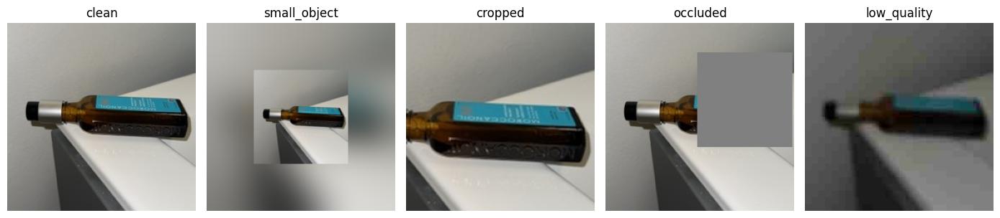

A2_CustomCNN_w384    val robust mean  65.7% | test robust mean  67.0%
C_ResNet50           val robust mean  79.0% | test robust mean  79.0%
D_EfficientNetB0     val robust mean  81.6% | test robust mean  81.8%
E_ConvNeXtT          val robust mean  84.0% | test robust mean  84.7%
G_DenseNet121        val robust mean  73.9% | test robust mean  73.6%

TEST accuracy under each condition:


,clean,small_object,cropped,occluded,low_quality,robust_mean,mean_drop
A2_CustomCNN_w384,89.06,76.68,90.12,74.95,26.10,66.96,22.10
C_ResNet50,98.66,95.20,98.08,89.64,32.92,78.96,19.70
D_EfficientNetB0,98.75,94.82,97.98,89.44,45.01,81.81,16.94
E_ConvNeXtT,99.23,97.60,98.46,91.17,51.73,84.74,14.49
G_DenseNet121,98.66,93.47,98.18,82.82,19.87,73.59,25.07


In [ ]:
def perturb(img, kind, rng):
    w, h = img.size
    if kind == "small_object":
        canvas = img.filter(ImageFilter.GaussianBlur(20)); sw, sh = w // 2, h // 2
        canvas.paste(img.resize((sw, sh), Image.BICUBIC), ((w - sw) // 2, (h - sh) // 2)); return canvas
    if kind == "cropped":
        cw, ch = int(w * 0.7), int(h * 0.7); x, y = int(rng.integers(0, w - cw + 1)), int(rng.integers(0, h - ch + 1))
        return img.crop((x, y, x + cw, y + ch)).resize((w, h), Image.BICUBIC)
    if kind == "occluded":
        img = img.copy(); ow, oh = w // 2, h // 2
        x, y = int(rng.integers(0, w - ow + 1)), int(rng.integers(0, h - oh + 1))
        ImageDraw.Draw(img).rectangle([x, y, x + ow, y + oh], fill=(128, 128, 128)); return img
    if kind == "low_quality":
        img = img.resize((w // 4, h // 4), Image.BILINEAR).resize((w, h), Image.BILINEAR)
        img = ImageEnhance.Brightness(img).enhance(0.6)
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=20); buf.seek(0)
        return Image.open(buf).convert("RGB")
    return img

PERTURBS = ["small_object", "cropped", "occluded", "low_quality"]
def make_pil_fn(kind, offset=0):
    return lambda img, i: perturb(img, kind, np.random.default_rng(SEED * 1000 + offset + i))

ex_path = test_df[~test_df.fname.isin(PRIVATE_FILES)].path.iloc[0]; ex = load_rgb(ex_path)
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, k in zip(axes, ["clean"] + PERTURBS):
    ax.imshow(ex if k == "clean" else make_pil_fn(k)(ex, 0)); ax.set_title(k); ax.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "perturbations.png", dpi=120); plt.show()

rob_val, rob_test = {}, {}
for name in NAMES:
    m = load_best(name)
    rob_val[name]  = {"clean": 100 * accuracy_score(y_val,  PROBS[name]["val"].argmax(1))}
    rob_test[name] = {"clean": 100 * accuracy_score(y_test, PROBS[name]["test"].argmax(1))}
    for k in PERTURBS:
        rob_val[name][k]  = 100 * accuracy_score(y_val,  predict_probs(m, val_df,  pil_fn=make_pil_fn(k, 500_000)).argmax(1))
        rob_test[name][k] = 100 * accuracy_score(y_test, predict_probs(m, test_df, pil_fn=make_pil_fn(k)).argmax(1))
    del m; torch.cuda.empty_cache()
    print(f"{name:20s} val robust mean {np.mean([rob_val[name][k] for k in PERTURBS]):5.1f}% | "
          f"test robust mean {np.mean([rob_test[name][k] for k in PERTURBS]):5.1f}%")

robust_val_df, robust_df = pd.DataFrame(rob_val).T.round(2), pd.DataFrame(rob_test).T.round(2)
for d in (robust_val_df, robust_df):
    d["robust_mean"] = d[PERTURBS].mean(1).round(2); d["mean_drop"] = (d["clean"] - d["robust_mean"]).round(2)
robust_val_df.to_csv(Path(SAVE_DIR, "robustness_val.csv")); robust_df.to_csv(Path(SAVE_DIR, "robustness_test.csv"))
results["val_robust_mean"] = robust_val_df.robust_mean; results["test_robust_mean"] = robust_df.robust_mean
results.to_csv(Path(SAVE_DIR, "model_comparison.csv"))
print("\nTEST accuracy under each condition:"); robust_df

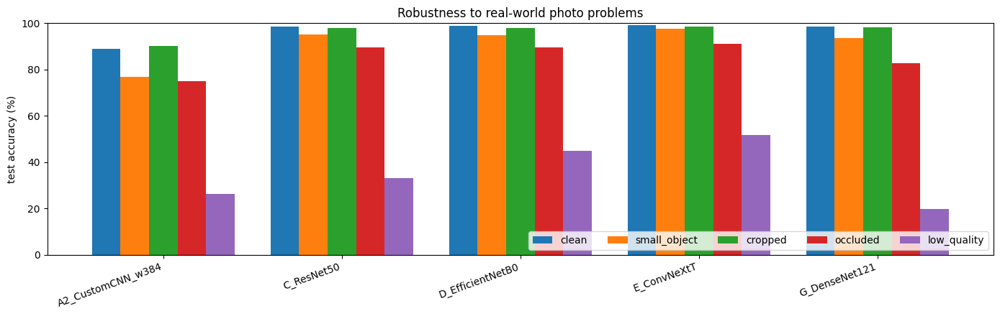

In [ ]:
ax = robust_df[["clean"] + PERTURBS].plot.bar(figsize=(14, 4.5), width=0.8)
ax.set_ylabel("test accuracy (%)"); ax.set_title("Robustness to real-world photo problems"); ax.set_ylim(0, 100)
plt.xticks(rotation=20, ha="right"); plt.legend(ncol=5, loc="lower right"); plt.tight_layout()
plt.savefig(FIG_DIR / "robustness.png", dpi=150); plt.show()

## 11. Model selection (validation data only)
1. Keep every model within **0.5 points** of the best validation macro-F1. Near 99%, clean validation can't separate the top models, since they differ by 1–3 images.
2. Among those, choose the highest **mean accuracy on the perturbed validation images**, i.e. the most robust model.
3. If that's still tied, choose the **fewest parameters**.

The test set plays no part in this choice, so the reported test numbers are unbiased.

In [ ]:
best_val = results.val_f1.max()
contenders = results[results.val_f1 >= best_val - 0.5].sort_values(["val_robust_mean", "params_M"], ascending=[False, True])
SELECTED = contenders.index[0]
size_only = results[results.val_f1 >= best_val - 0.5].sort_values("params_M").index[0]
print("Step 1 - validation macro-F1:\n", results.val_f1.sort_values(ascending=False).to_string())
print(f"\nWithin 0.5 pt of best ({best_val:.2f}):")
print(contenders[["val_f1", "val_robust_mean", "params_M"]].to_string())
print(f"\nSELECTED MODEL: {SELECTED}")
if size_only != SELECTED:
    print(f"(Transparency: a size-only tie-break would have picked {size_only}.)")
r = results.loc[SELECTED]
print(f"Test: acc {r.test_acc:.2f}% {r.acc_95CI} | macro-F1 {r.test_f1:.2f}% | hard subset {r.hard_acc:.2f}% | "
      f"robust mean {r.test_robust_mean:.1f}% | {r.params_M:.1f} M params | {r.ms_per_img:.2f} ms/img")
contenders.to_csv(Path(SAVE_DIR, "selection_validation.csv"))

Step 1 - validation macro-F1:
 model
E_ConvNeXtT          99.61
D_EfficientNetB0     99.41
C_ResNet50           99.22
G_DenseNet121        99.13
A2_CustomCNN_w384    89.56

Within 0.5 pt of best (99.61):
                  val_f1  val_robust_mean  params_M
model                                              
E_ConvNeXtT        99.61            83.98     27.88
D_EfficientNetB0   99.41            81.63      4.10
C_ResNet50         99.22            79.04     23.66
G_DenseNet121      99.13            73.87      7.03

SELECTED MODEL: E_ConvNeXtT
(Transparency: a size-only tie-break would have picked D_EfficientNetB0.)
Test: acc 99.23% [98.7, 99.7] | macro-F1 99.23% | hard subset 99.15% | robust mean 84.7% | 27.9 M params | 1.43 ms/img


### McNemar exact tests
The test only uses images where exactly one of the two models is correct. p < 0.05 means the accuracy difference is real, not noise.

In [ ]:
def mcnemar(y, pa, pb):
    a, b = pa == y, pb == y
    n01, n10 = int(np.sum(a & ~b)), int(np.sum(~a & b))
    p = binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 else 1.0
    return n01, n10, p

pred_test = {n: PROBS[n]["test"].argmax(1) for n in NAMES}
mc_rows = []
for other in NAMES:
    if other == SELECTED: continue
    n01, n10, p = mcnemar(y_test, pred_test[SELECTED], pred_test[other])
    mc_rows.append(dict(compared_with=other, only_selected_correct=n01, only_other_correct=n10,
                        p_value=round(p, 4), significant="yes" if p < 0.05 else "no"))
mcnemar_df = pd.DataFrame(mc_rows).set_index("compared_with")
mcnemar_df.to_csv(Path(SAVE_DIR, "significance_mcnemar.csv"))
print(f"McNemar vs selected model ({SELECTED}):"); print(mcnemar_df.to_string())

pmat = pd.DataFrame(index=NAMES, columns=NAMES, dtype=float)
for a in NAMES:
    for b in NAMES:
        pmat.loc[a, b] = 1.0 if a == b else mcnemar(y_test, pred_test[a], pred_test[b])[2]
pmat.round(4).to_csv(Path(SAVE_DIR, "mcnemar_all_pairs.csv"))
print("All-pairs p-values saved to mcnemar_all_pairs.csv")

McNemar vs selected model (E_ConvNeXtT):
                   only_selected_correct  only_other_correct  p_value significant
compared_with                                                                    
A2_CustomCNN_w384                    110                   4   0.0000         yes
C_ResNet50                            11                   5   0.2101          no
D_EfficientNetB0                      10                   5   0.3018          no
G_DenseNet121                          9                   3   0.1460          no
All-pairs p-values saved to mcnemar_all_pairs.csv


## 12. Training curves

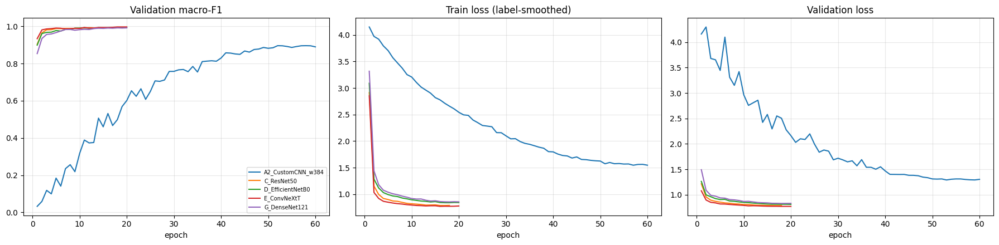

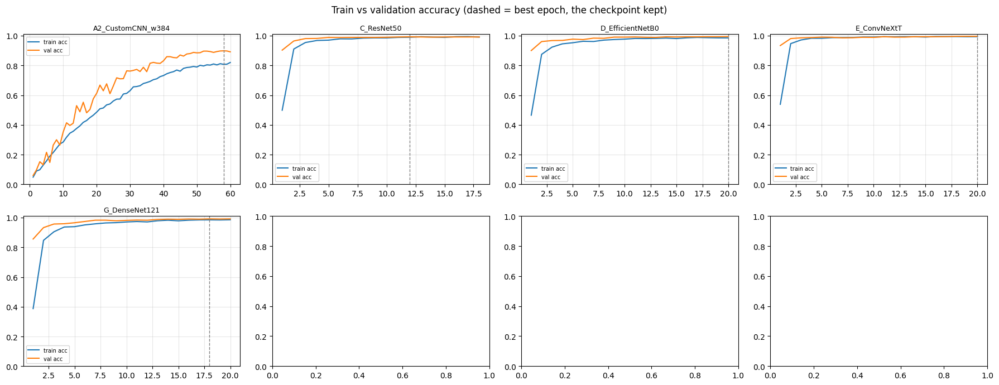

In [ ]:
H = {n: pd.read_csv(Path(SAVE_DIR, f"{n}_history.csv")) for n in NAMES}
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for n, h in H.items():
    axes[0].plot(h.epoch, h.val_f1, label=n); axes[1].plot(h.epoch, h.train_loss, label=n); axes[2].plot(h.epoch, h.val_loss, label=n)
for ax, t in zip(axes, ["Validation macro-F1", "Train loss (label-smoothed)", "Validation loss"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(FIG_DIR / "training_curves_all.png", dpi=150); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, (n, h) in zip(axes.flat, H.items()):
    ax.plot(h.epoch, h.train_acc, label="train acc"); ax.plot(h.epoch, h.val_acc, label="val acc")
    ax.axvline(TRAIN_META[n]["best_epoch"], color="gray", ls="--", lw=1)
    ax.set_title(n, fontsize=9); ax.set_ylim(0, 1.01); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("Train vs validation accuracy (dashed = best epoch, the checkpoint kept)")
plt.tight_layout(); plt.savefig(FIG_DIR / "training_curves_per_model.png", dpi=150); plt.show()

## 13. Misclassified images: every model, validation and test
For each model and split, a grid shows up to 16 mistakes, most confident first, with the true and predicted Object ID.
**Every** wrong image from every model is listed in `misclassified_all_models.csv`.
Images that several models get wrong are usually look-alikes, multi-object scenes or poor photos, not model bugs.

Number of mistakes per model:
split              test  val
model                       
A2_CustomCNN_w384   114  106
C_ResNet50           14    8
D_EfficientNetB0     13    6
E_ConvNeXtT           8    4
G_DenseNet121        14    9


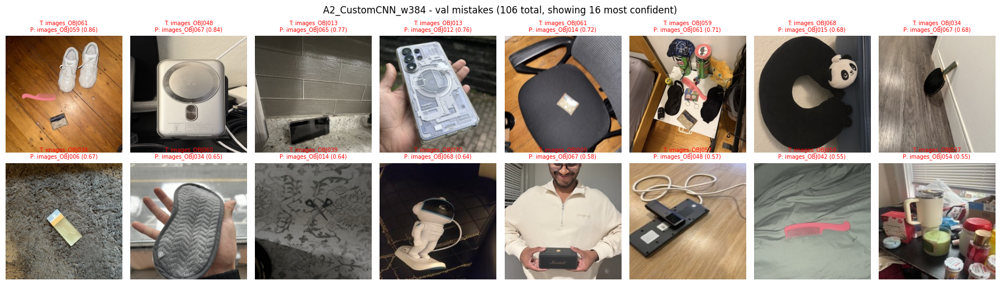

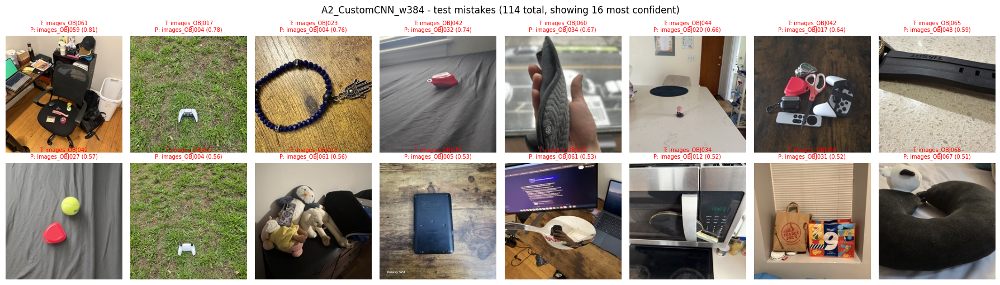

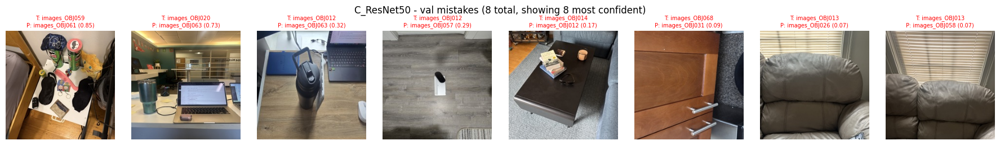

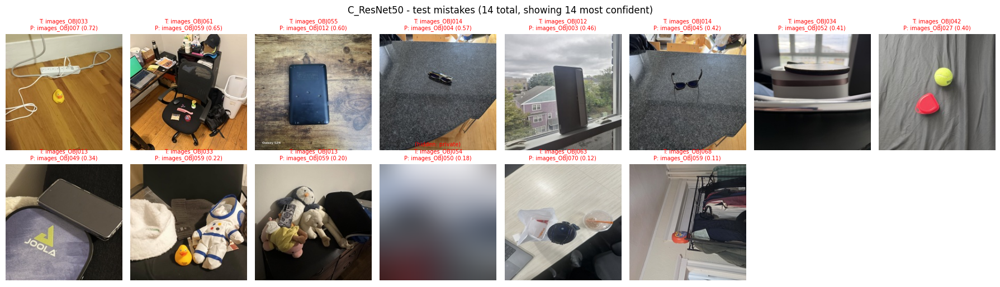

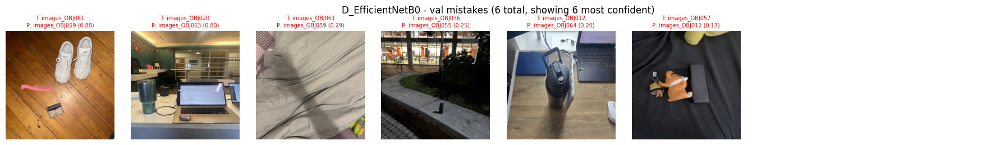

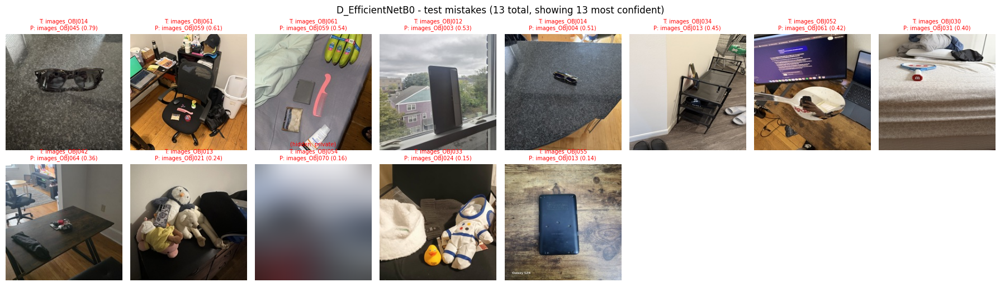

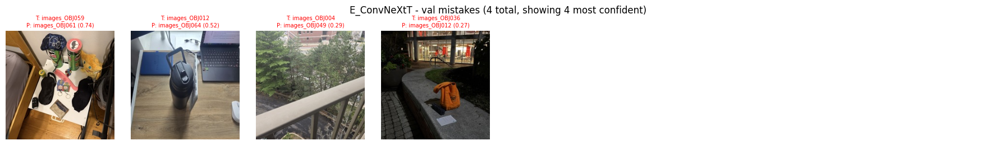

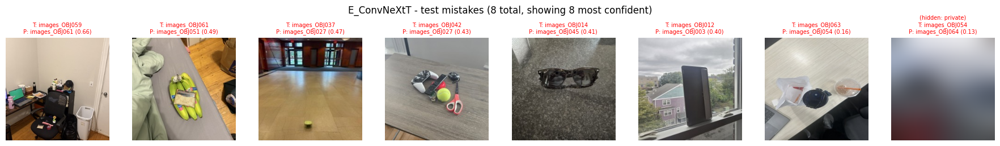

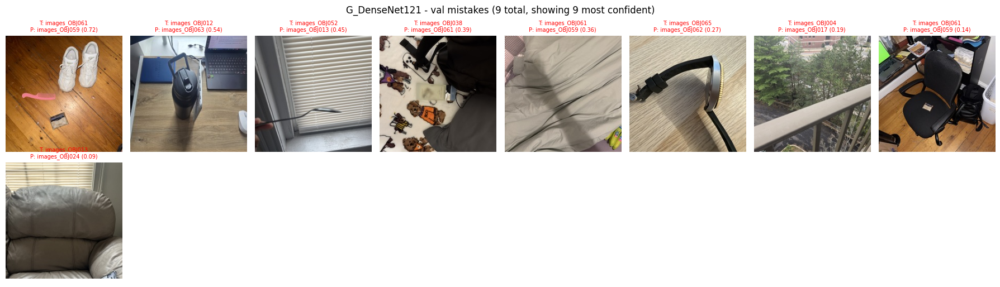

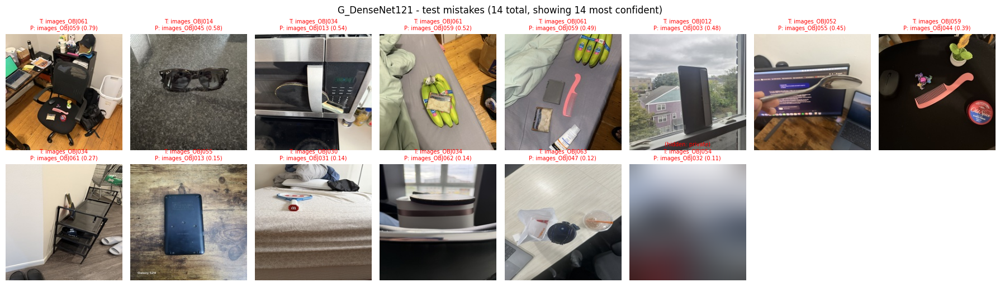

In [ ]:
SPLITS = {"val": (val_df, y_val), "test": (test_df, y_test)}
err_rows = []
for name in NAMES:
    for split, (frame, y) in SPLITS.items():
        probs = PROBS[name][split]; pred, conf = probs.argmax(1), probs.max(1)
        wrong = np.where(pred != y)[0]
        for i in wrong:
            err_rows.append(dict(model=name, split=split, path=frame.path.iloc[i], fname=frame.fname.iloc[i],
                                 true=CLASSES[y[i]], pred=CLASSES[pred[i]], confidence=round(float(conf[i]), 3)))
errors_df = pd.DataFrame(err_rows, columns=["model", "split", "path", "fname", "true", "pred", "confidence"])
errors_df.to_csv(Path(SAVE_DIR, "misclassified_all_models.csv"), index=False)
print("Number of mistakes per model:")
print(errors_df.groupby(["model", "split"]).size().unstack(fill_value=0).reindex(NAMES, fill_value=0).to_string())

def error_grid(name, split, k=16):
    e = errors_df[(errors_df.model == name) & (errors_df.split == split)].sort_values("confidence", ascending=False)
    if e.empty:
        print(f"{name} / {split}: no mistakes"); return
    shown = e.head(k); ncol = 8; nrow = int(math.ceil(len(shown) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.6 * nrow)); axes = np.atleast_2d(axes)
    for ax in axes.flat: ax.axis("off")
    for ax, (_, r) in zip(axes.flat, shown.iterrows()):
        show_img(ax, r.path, f"T: {r.true}\nP: {r.pred} ({r.confidence:.2f})", "red")
    plt.suptitle(f"{name} - {split} mistakes ({len(e)} total, showing {len(shown)} most confident)")
    plt.tight_layout(); plt.savefig(FIG_DIR / f"misclassified_{name}_{split}.png", dpi=110); plt.show()

for name in NAMES:
    for split in SPLITS:
        error_grid(name, split)

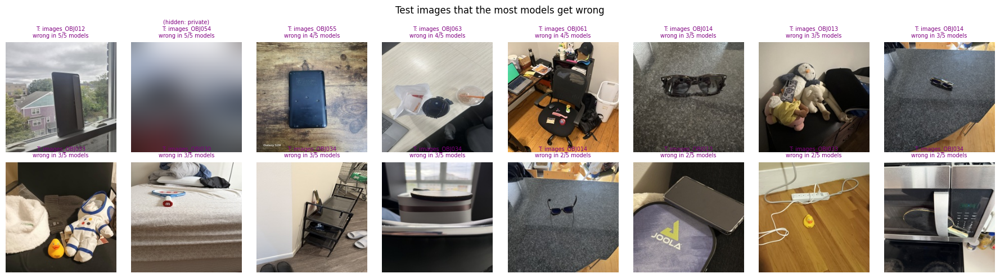

In [ ]:
# Images that MANY models get wrong (likely hard or ambiguous photos)
hardest = (errors_df[errors_df.split == "test"].groupby(["path", "fname", "true"]).model.nunique()
           .rename("n_models_wrong").reset_index().sort_values("n_models_wrong", ascending=False))
hardest.to_csv(Path(SAVE_DIR, "hardest_test_images.csv"), index=False)
top = hardest.head(16)
if len(top):
    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for ax in axes.flat: ax.axis("off")
    for ax, (_, r) in zip(axes.flat, top.iterrows()):
        show_img(ax, r.path, f"T: {r.true}\nwrong in {r.n_models_wrong}/{len(NAMES)} models", "purple")
    plt.suptitle("Test images that the most models get wrong"); plt.tight_layout()
    plt.savefig(FIG_DIR / "hardest_test_images.png", dpi=110); plt.show()

## 14. Error analysis of the selected model

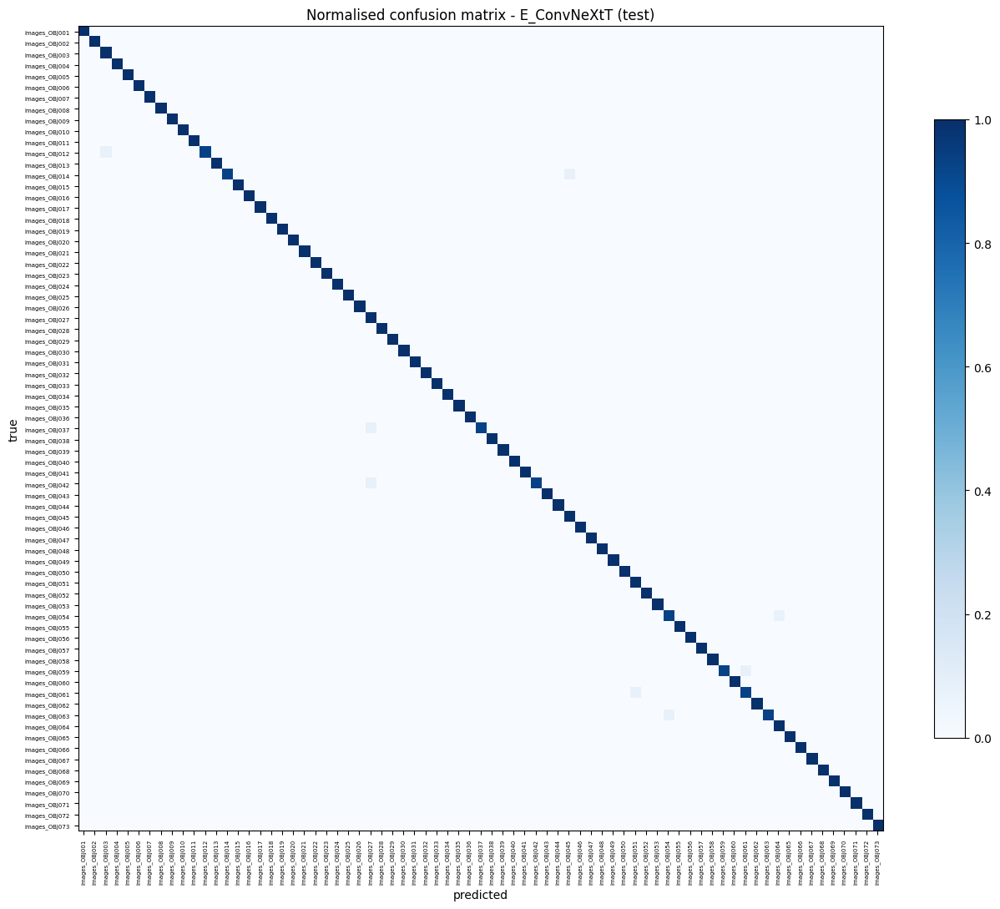

60 of 73 classes classified perfectly on test.

10 weakest classes:
                precision  recall  f1-score  support
images_OBJ061      0.929   0.929     0.929     14.0
images_OBJ027      0.875   1.000     0.933     14.0
images_OBJ054      0.933   0.933     0.933     15.0
images_OBJ014      1.000   0.929     0.963     14.0
images_OBJ042      1.000   0.929     0.963     14.0
images_OBJ037      1.000   0.929     0.963     14.0
images_OBJ012      1.000   0.929     0.963     14.0
images_OBJ063      1.000   0.929     0.963     14.0
images_OBJ059      1.000   0.929     0.963     14.0
images_OBJ045      0.933   1.000     0.966     14.0

Most frequent confusions (count, true -> predicted):
    1  images_OBJ063 -> images_OBJ054
    1  images_OBJ061 -> images_OBJ051
    1  images_OBJ059 -> images_OBJ061
    1  images_OBJ054 -> images_OBJ064
    1  images_OBJ042 -> images_OBJ027
    1  images_OBJ037 -> images_OBJ027
    1  images_OBJ014 -> images_OBJ045
    1  images_OBJ012 -> images_OBJ003



In [ ]:
pred_sel = pred_test[SELECTED]
cm = confusion_matrix(y_test, pred_sel, labels=range(NUM_CLASSES))
cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=90, fontsize=5)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES, fontsize=5)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"Normalised confusion matrix - {SELECTED} (test)")
plt.colorbar(im, fraction=0.03); plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrix_selected.png", dpi=200); plt.show()

rep = pd.DataFrame(classification_report(y_test, pred_sel, labels=range(NUM_CLASSES), target_names=CLASSES,
                                         output_dict=True, zero_division=0)).T
rep.to_csv(Path(SAVE_DIR, "per_class_selected.csv"))
per_class = rep.loc[CLASSES]
print(f"{int((per_class['f1-score'] == 1).sum())} of {NUM_CLASSES} classes classified perfectly on test.")
weak = per_class.sort_values("f1-score").head(10)
print("\n10 weakest classes:\n", weak[["precision", "recall", "f1-score", "support"]].round(3).to_string())
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j], CLASSES[i], CLASSES[j]) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if off[i, j]), reverse=True)[:10]
print("\nMost frequent confusions (count, true -> predicted):")
for n, t, p in pairs: print(f"  {n:3d}  {t} -> {p}")
conf_sel = PROBS[SELECTED]["test"].max(1)
print(f"\nMean confidence: correct {conf_sel[pred_sel == y_test].mean():.3f} | wrong "
      f"{conf_sel[pred_sel != y_test].mean() if (pred_sel != y_test).any() else float('nan'):.3f}")

## 15. Grad-CAM: where does each model look?
The same 6 test images are shown for every model: 4 that the selected model gets right and up to 2 it gets wrong.
Heat on the object is good. Heat on the table, wall or floor means the model is relying on background cues.

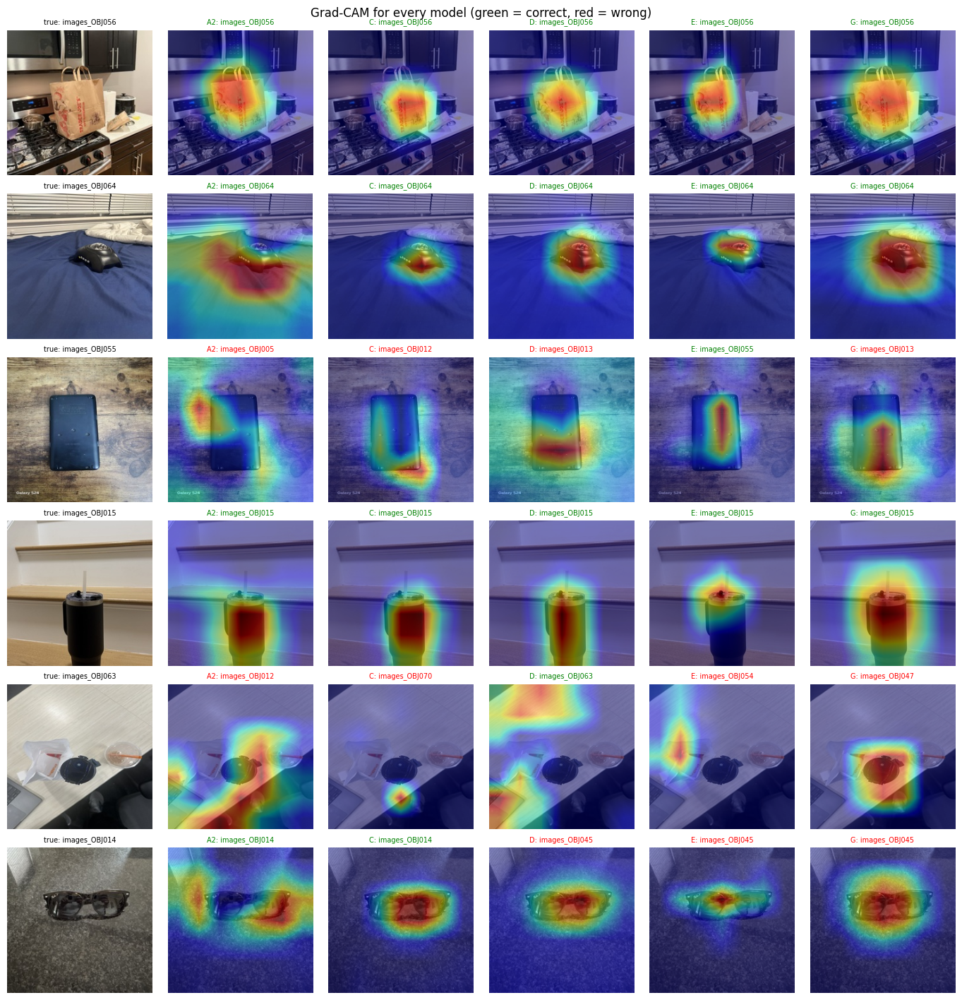

In [ ]:
class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        for p in model.parameters(): p.requires_grad_(True)       # needed for the frozen linear-probe model too
        self.h = layer.register_forward_hook(self._hook)
    def _hook(self, module, inp, out):
        self.acts = out
        if out.requires_grad: out.register_hook(lambda g: setattr(self, "grads", g))
    def __call__(self, x):
        self.model.eval(); self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = self.model(x)
            cls = logits.argmax(1)
            logits.gather(1, cls[:, None]).sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True)).detach()
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
        cam = cam - cam.amin(dim=(1, 2), keepdim=True)
        cam = cam / cam.amax(dim=(1, 2), keepdim=True).clamp(min=1e-8)
        return cam.cpu().numpy(), cls.cpu().numpy()
    def remove(self): self.h.remove()

rng = np.random.default_rng(SEED)
ok_idx = np.where((pred_sel == y_test) & ~test_df.fname.isin(PRIVATE_FILES).values)[0]
bad_idx = np.where((pred_sel != y_test) & ~test_df.fname.isin(PRIVATE_FILES).values)[0]
idx = list(rng.choice(ok_idx, size=min(4, len(ok_idx)), replace=False)) + list(bad_idx[:2])
x = torch.stack([eval_tf(load_rgb(test_df.path.iloc[i])) for i in idx]).to(DEVICE)

cams = {}
for name in NAMES:
    m = load_best(name); g = GradCAM(m, MODEL_SPECS[name]["cam_layer"](m))
    cams[name] = g(x); g.remove(); del m, g; torch.cuda.empty_cache()

cols = ["image"] + NAMES
fig, axes = plt.subplots(len(idx), len(cols), figsize=(2.3 * len(cols), 2.4 * len(idx)))
axes = np.atleast_2d(axes)
for r, i in enumerate(idx):
    img = denorm(x[r])
    axes[r, 0].imshow(img); axes[r, 0].set_title(f"true: {CLASSES[y_test[i]]}", fontsize=7)
    for c, name in enumerate(NAMES, start=1):
        cam, cls = cams[name]
        axes[r, c].imshow(img); axes[r, c].imshow(cam[r], cmap="jet", alpha=0.45)
        axes[r, c].set_title(f"{name.split('_')[0]}: {CLASSES[cls[r]]}", fontsize=7,
                             color="green" if cls[r] == y_test[i] else "red")
for ax in axes.flat: ax.axis("off")
plt.suptitle("Grad-CAM for every model (green = correct, red = wrong)"); plt.tight_layout()
plt.savefig(FIG_DIR / "gradcam_all_models.png", dpi=150); plt.show()

## 16. Background-shortcut test
The background-only photos removed in Section 2 contain **no object**. If a model predicts the photographer's own Object ID for an empty scene far above chance (1/73 ≈ 1.4%), it has learned to use the room as a clue.
Low confidence on those images is reassuring. It means the model treats the background only as a weak, secondary cue.

In [ ]:
bg_eval = bg_df[bg_df.label.isin(CLASS_TO_IDX)].copy()
bg_table = None
if len(bg_eval) == 0:
    print("No background images found - test skipped.")
else:
    bg_eval["label_idx"] = bg_eval.label.map(CLASS_TO_IDX)
    bg_rows = []
    for name in NAMES:
        m = load_best(name); pb = predict_probs(m, bg_eval); del m; torch.cuda.empty_cache()
        bg_rows.append(dict(model=name, n_bg_images=len(bg_eval),
                            own_id_predicted_pct=100 * np.mean(pb.argmax(1) == bg_eval.label_idx.values),
                            chance_pct=100 / NUM_CLASSES,
                            mean_conf_on_bg=pb.max(1).mean(),
                            mean_conf_on_test_objects=PROBS[name]["test"].max(1).mean()))
    bg_table = pd.DataFrame(bg_rows).set_index("model").round(3)
    bg_table.to_csv(Path(SAVE_DIR, "background_shortcut.csv"))
    print(bg_table.to_string())

                   n_bg_images  own_id_predicted_pct  chance_pct  mean_conf_on_bg  mean_conf_on_test_objects
model                                                                                                       
A2_CustomCNN_w384          378                33.069        1.37            0.377                      0.799
C_ResNet50                 378                36.508        1.37            0.346                      0.867
D_EfficientNetB0           378                38.095        1.37            0.376                      0.886
E_ConvNeXtT                378                35.714        1.37            0.356                      0.890
G_DenseNet121              378                34.656        1.37            0.332                      0.867


## 17. Results summary for the report

In [ ]:
def md_table(d):
    try: return d.to_markdown()
    except ImportError: return "```\n" + d.to_string() + "\n```"

main_cols = ["val_f1", "test_acc", "acc_95CI", "test_f1", "hard_acc", "top5_acc", "tta_acc", "test_robust_mean",
             "test_errors", "params_M", "train_min", "ms_per_img"]
lines = [
    "# IE7615 Milestone 1 - results summary", "",
    "## Data",
    f"- Indexed images: {len(raw_df)} in {raw_df.label.nunique()} folders; junk entries skipped: {len(junk)}; corrupt: {len(bad)}",
    f"- Background-only images removed: {n_bg_raw} (filename tags _bg_ / BG###; OBJ004 has no tags, so its background shots stay in)",
    f"- Exact duplicates removed from object photos (MD5, after background removal): {n_dup} same-class + {n_conflict} cross-class",
    f"- Final: {len(obj_df)} images, {NUM_CLASSES} classes, {counts.final.min()}-{counts.final.max()} per class",
    f"- Split 70/15/15 stratified, seed {SEED}: train {len(train_df)} / val {len(val_df)} / test {len(test_df)}",
    f"- Label audit (5-fold out-of-fold): {100*np.mean(all_df.oof_pred == all_df.label_idx):.1f}% ; suspects: {len(suspects)}",
    f"- Near-duplicate test images (cos >= {NEAR_DUP_THRESHOLD}): {int((~test_df.hard).sum())}; hard subset: {int(test_df.hard.sum())}",
    f"- Class-weighted loss: {'on' if CLASS_WEIGHTS is not None else 'off'} (train ratio {imbalance:.2f})", "",
    "Note: the pretrained models were shortlisted from earlier experiments (group members' exploratory runs); the final model is chosen on validation data only.", "",
    "## Models", md_table(arch_df[["description", "params_M", "trainable_M", "epochs", "batch", "lr_head", "lr_backbone", "aug"]]), "",
    "## Main comparison (test set)", md_table(results[main_cols]), "",
    "## Selection (validation only)", md_table(contenders[["val_f1", "val_robust_mean", "params_M"]]), "",
    f"**Selected model: {SELECTED}** - rule: within 0.5 pt of best val macro-F1 -> highest perturbed-val accuracy -> fewest params.", "",
    "## McNemar exact test vs selected model", md_table(mcnemar_df), "",
    "## Robustness (test accuracy %)", md_table(robust_df), "",
]
if bg_table is not None: lines += ["## Background-shortcut test", md_table(bg_table), ""]
lines += ["## Mistakes per model", md_table(errors_df.groupby(["model", "split"]).size().unstack(fill_value=0)), "",
          "## Weakest classes (selected model)", md_table(weak[["precision", "recall", "f1-score", "support"]].round(3))]
Path(SAVE_DIR, "results_summary.md").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))
print("\nAll outputs saved in", SAVE_DIR)

# IE7615 Milestone 1 - results summary

## Data
- Indexed images: 7343 in 73 folders; junk entries skipped: 2; corrupt: 0
- Background-only images removed: 385 (filename tags _bg_ / BG###; OBJ004 has no tags, so its background shots stay in)
- Exact duplicates removed from object photos (MD5, after background removal): 16 same-class + 0 cross-class
- Final: 6942 images, 73 classes, 89-106 per class
- Split 70/15/15 stratified, seed 42: train 4859 / val 1041 / test 1042
- Label audit (5-fold out-of-fold): 97.9% ; suspects: 50
- Near-duplicate test images (cos >= 0.92): 99; hard subset: 943
- Class-weighted loss: on (train ratio 1.19)

Note: the pretrained models were shortlisted from earlier experiments (group members' exploratory runs); the final model is chosen on validation data only.

## Models
| model             | description                                       |   params_M |   trainable_M |   epochs |   batch |   lr_head |   lr_backbone | aug    |
|:------------------|:--------

In [ ]:
# Make a PDF of the results summary (+ key figures) and download it
!pip -q install markdown xhtml2pdf
import markdown
from xhtml2pdf import pisa

md_text = Path(SAVE_DIR, "results_summary.md").read_text(encoding="utf-8")
body = markdown.markdown(md_text, extensions=["tables", "fenced_code"])

figs = [("Images per class", "class_counts.png"),
        ("Training curves", "training_curves_all.png"),
        ("Train vs validation accuracy", "training_curves_per_model.png"),
        ("Robustness", "robustness.png"),
        ("Perturbation examples", "perturbations.png"),
        (f"Confusion matrix - {SELECTED}", "confusion_matrix_selected.png"),
        (f"Test mistakes - {SELECTED}", f"misclassified_{SELECTED}_test.png"),
        ("Grad-CAM", "gradcam_all_models.png")]
for title, f in figs:
    p = FIG_DIR / f
    if p.exists():
        body += f'<pdf:nextpage /><h2>{title}</h2><img src="{p}" width="740">'

html = f"""<html><head><meta charset="utf-8"><style>
@page {{ size: a4 landscape; margin: 1.3cm; }}
body {{ font-family: Helvetica; font-size: 9pt; }}
h1 {{ font-size: 16pt; color: #1F3A5F; }}
h2 {{ font-size: 12pt; color: #1F3A5F; margin-top: 10pt; }}
table {{ border-collapse: collapse; width: 100%; }}
th {{ background: #1F3A5F; color: white; font-size: 7.5pt; padding: 3px; }}
td {{ border: 0.5px solid #B8C7D9; font-size: 7.5pt; padding: 3px; }}
pre {{ font-size: 7pt; }}
</style></head><body>{body}</body></html>"""

pdf_path = Path(SAVE_DIR, "results_summary.pdf")
with open(pdf_path, "wb") as f:
    status = pisa.CreatePDF(html, dest=f, encoding="utf-8")
print("PDF saved to", pdf_path, "| errors:", status.err)

from google.colab import files
files.download(str(pdf_path))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.3/477.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.6/194.6 kB 9.6 MB/s eta 0:00:00


PDF saved to /content/drive/MyDrive/IE7615_project_v3/results_summary.pdf | errors: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>